# Global Literacy & Education Trends: An Analytical Study

## Install & Import Libraries

In [5]:
# Install required libraries (run once)
# !pip install pandas numpy matplotlib seaborn plotly requests sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests 
from io import StringIO
import sqlite3
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(' All libraries imported successfully!')

 All libraries imported successfully!


## Dataset Collection 

In [6]:
# ── Dataset URLs ──────────────────────────────────────────────────────────────
URLS = {
    'adult_literacy'    : 'https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true',
    'youth_literacy'    : 'https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true',
    'illiteracy_pop'    : 'https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true',
    'gdp_per_capita'    : 'https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true',
    'years_schooling'   : 'https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true',
}

raw = {}

for name, url in URLS.items():
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers)
        data = StringIO(response.text)
        raw[name] = pd.read_csv(data)

        print(f'{name:20s} → {raw[name].shape}')

    except Exception as e:
        print(f'{name}: {e}')

adult_literacy       → (1725, 4)
youth_literacy       → (2002, 6)
illiteracy_pop       → (2059, 5)
gdp_per_capita       → (7240, 5)
years_schooling      → (5365, 7)


In [8]:
# Quick preview of each raw dataset
for name, df in raw.items():
    print(f'\n── {name} ──')
    print(df.head(3).to_string())
    print('Columns:', list(df.columns))


── adult_literacy ──
        entity code  year  adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0  Afghanistan  AFG  1979                                                                      18.00
1  Afghanistan  AFG  2011                                                                      31.00
2  Afghanistan  AFG  2015                                                                      33.75
Columns: ['entity', 'code', 'year', 'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99']

── youth_literacy ──
        entity code  year  youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m  youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f owid_region
0  Afghanistan  AFG  1979                                                                 46.00                                                                   11.00        Asia
1  Afghanistan  AFG  2011                                                      

---
## Data Understanding 

In [9]:
def dataset_summary(df, name):
    print(f'\n{'='*60}')
    print(f'  {name}')
    print(f'{'='*60}')
    print(f'  Shape  : {df.shape}')
    print(f'  Columns: {list(df.columns)}')
    print(f'  Dtypes :\n{df.dtypes}')
    print(f'\n  Missing Values:\n{df.isnull().sum()}')
    print(f'\n  Duplicates: {df.duplicated().sum()}')
    display(df.describe())

for name, df in raw.items():
    dataset_summary(df, name)


  adult_literacy
  Shape  : (1725, 4)
  Columns: ['entity', 'code', 'year', 'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99']
  Dtypes :
entity                                                                        object
code                                                                          object
year                                                                           int64
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99    float64
dtype: object

  Missing Values:
entity                                                                         0
code                                                                         729
year                                                                           0
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99      0
dtype: int64

  Duplicates: 0


,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
count,1725.00,1725.00
mean,2003.86,77.34
std,13.18,19.34
min,1970.00,9.00
25%,1994.00,64.49
50%,2007.00,82.16
75%,2015.00,94.00
max,2023.00,100.00



  youth_literacy
  Shape  : (2002, 6)
  Columns: ['entity', 'code', 'year', 'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m', 'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f', 'owid_region']
  Dtypes :
entity                                                                     object
code                                                                       object
year                                                                        int64
youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m      float64
youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f    float64
owid_region                                                                object
dtype: object

  Missing Values:
entity                                                                      0
code                                                                      742
year                                                                  

,year,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f
count,2002.00,1925.00,2002.00
mean,2004.84,89.39,84.05
std,12.77,12.57,19.45
min,1970.00,22.00,7.00
25%,1997.00,84.00,73.83
50%,2007.00,94.40,93.59
75%,2015.00,98.60,98.91
max,2023.00,100.00,100.00



  illiteracy_pop
  Shape  : (2059, 5)
  Columns: ['entity', 'code', 'year', 'illiteracy_rate', 'literacy_rate']
  Dtypes :
entity              object
code                object
year                 int64
illiteracy_rate    float64
literacy_rate      float64
dtype: object

  Missing Values:
entity               0
code               733
year                 0
illiteracy_rate      0
literacy_rate        0
dtype: int64

  Duplicates: 0


,year,illiteracy_rate,literacy_rate
count,2059.00,2059.00,2059.00
mean,1986.08,27.42,72.58
std,64.01,24.49,24.49
min,1475.00,0.00,0.00
25%,1983.00,6.70,57.98
50%,2002.00,21.00,79.00
75%,2013.00,42.02,93.30
max,2023.00,100.00,100.00



  gdp_per_capita
  Shape  : (7240, 5)
  Columns: ['entity', 'code', 'year', 'ny_gdp_pcap_pp_kd', 'owid_region']
  Dtypes :
entity                object
code                  object
year                   int64
ny_gdp_pcap_pp_kd    float64
owid_region           object
dtype: object

  Missing Values:
entity                 0
code                   0
year                   0
ny_gdp_pcap_pp_kd      0
owid_region          455
dtype: int64

  Duplicates: 0


,year,ny_gdp_pcap_pp_kd
count,7240.00,7240.00
mean,2007.20,21842.84
std,10.06,23830.95
min,1990.00,510.82
25%,1999.00,4520.73
50%,2007.00,12714.60
75%,2016.00,32586.05
max,2024.00,174569.52



  years_schooling
  Shape  : (5365, 7)
  Columns: ['entity', 'code', 'year', 'literacy_rate', 'mf_youth_and_adults__15_64_years__average_years_of_education', 'population_historical', 'owid_region']
  Dtypes :
entity                                                           object
code                                                             object
year                                                              int64
literacy_rate                                                   float64
mf_youth_and_adults__15_64_years__average_years_of_education    float64
population_historical                                           float64
owid_region                                                      object
dtype: object

  Missing Values:
entity                                                             0
code                                                             890
year                                                               0
literacy_rate                                 

,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical
count,5365.00,2000.00,3668.00,4760.00
mean,1959.71,72.68,3.82,97527387.31
std,57.13,24.57,3.65,384817672.09
min,1475.00,0.00,0.00,1612.00
25%,1920.00,57.81,0.53,2018601.25
50%,1975.00,79.14,2.76,6498918.50
75%,2005.00,93.90,6.37,24874237.50
max,2023.00,100.00,13.74,4686811214.00



## Data Cleaning

In [10]:
# ── Helper: standardise column names ─────────────────────────────────────────
def clean_base(df):
    """Rename Entity→country, Code→iso_code, Year→year and lower-case the rest."""
    df = df.copy()
    rename_map = {}
    for col in df.columns:
        lc = col.strip()
        if lc in ('Entity', 'entity'):       rename_map[col] = 'country'
        elif lc in ('Code', 'code'):         rename_map[col] = 'iso_code'
        elif lc in ('Year', 'year'):         rename_map[col] = 'year'
        else:                                rename_map[col] = lc.lower().replace(' ', '_')
    df.rename(columns=rename_map, inplace=True)
    # keep only country-level rows (drop aggregates that have no ISO code)
    if 'iso_code' in df.columns:
        df = df[df['iso_code'].notna() & (df['iso_code'] != '')]
    # filter years 1990-2023
    if 'year' in df.columns:
        df = df[(df['year'] >= 1990) & (df['year'] <= 2023)]
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

print('clean_base() defined')

clean_base() defined


In [11]:
# ── Adult Literacy ────────────────────────────────────────────────────────────
df_adult = clean_base(raw['adult_literacy'])
# Identify the numeric column (adult literacy rate)
num_cols = [c for c in df_adult.columns if c not in ('country','iso_code','year')]
print('Adult literacy numeric cols:', num_cols)
df_adult.rename(columns={num_cols[0]: 'adult_literacy_rate'}, inplace=True)
df_adult['adult_literacy_rate'] = pd.to_numeric(df_adult['adult_literacy_rate'], errors='coerce')
df_adult.dropna(subset=['adult_literacy_rate'], inplace=True)
print(df_adult.shape, df_adult.head(3))

Adult literacy numeric cols: ['adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99']
(868, 4)        country iso_code  year  adult_literacy_rate
0  Afghanistan      AFG  2011                31.00
1  Afghanistan      AFG  2015                33.75
2  Afghanistan      AFG  2021                37.00


In [12]:
# ── Youth Literacy (Male & Female) ───────────────────────────────────────────
df_youth = clean_base(raw['youth_literacy'])
num_cols = [c for c in df_youth.columns if c not in ('country','iso_code','year')]
print('Youth literacy numeric cols:', num_cols)
# Expecting male and female columns; rename sensibly
if len(num_cols) >= 2:
    df_youth.rename(columns={num_cols[0]: 'youth_literacy_male',
                              num_cols[1]: 'youth_literacy_female'}, inplace=True)
elif len(num_cols) == 1:
    df_youth.rename(columns={num_cols[0]: 'youth_literacy_rate'}, inplace=True)
for c in df_youth.columns:
    if c not in ('country','iso_code','year'):
        df_youth[c] = pd.to_numeric(df_youth[c], errors='coerce')
df_youth.dropna(how='all', subset=[c for c in df_youth.columns if c not in ('country','iso_code','year')], inplace=True)
print(df_youth.shape, df_youth.head(3))

Youth literacy numeric cols: ['youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m', 'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f', 'owid_region']
(1133, 6)        country iso_code  year  youth_literacy_male  youth_literacy_female  \
0  Afghanistan      AFG  2011                62.00                  32.00   
1  Afghanistan      AFG  2015                57.74                  25.48   
2  Afghanistan      AFG  2021                71.00                  42.00   

   owid_region  
0          NaN  
1          NaN  
2          NaN  


In [14]:
# ── Illiteracy Population ─────────────────────────────────────────────────────
df_illit = clean_base(raw['illiteracy_pop'])

num_cols = [c for c in df_illit.columns if c not in ('country','iso_code','year')]
print('Illiteracy numeric cols:', num_cols)

# Map columns
col_map = {}
for c in num_cols:
    lc = c.lower()
    if 'illiterate' in lc and 'female' in lc:
        col_map[c] = 'illiterate_female'
    elif 'illiterate' in lc and 'male' in lc:
        col_map[c] = 'illiterate_male'
    elif 'illiterate' in lc:
        col_map[c] = 'illiterate_total'
    elif 'literate' in lc and 'female' in lc:
        col_map[c] = 'literate_female'
    elif 'literate' in lc and 'male' in lc:
        col_map[c] = 'literate_male'
    elif 'literate' in lc:
        col_map[c] = 'literate_total'

# Apply renaming
if col_map:
    df_illit.rename(columns=col_map, inplace=True)

# Convert numeric
for c in df_illit.columns:
    if c not in ('country','iso_code','year'):
        df_illit[c] = pd.to_numeric(df_illit[c], errors='coerce')

# SAFE CHECK (IMPORTANT FIX)
if 'illiterate_total' not in df_illit.columns:
    # fallback: pick last numeric column
    last_col = num_cols[-1]
    df_illit.rename(columns={last_col: 'illiterate_total'}, inplace=True)

# Derive total population
if 'literate_total' in df_illit.columns and 'illiterate_total' in df_illit.columns:
    df_illit['total_population'] = df_illit['literate_total'] + df_illit['illiterate_total']
    df_illit['illiteracy_pct'] = (df_illit['illiterate_total'] / df_illit['total_population']) * 100

# Drop NA safely
df_illit.dropna(subset=['illiterate_total'], inplace=True)

print(df_illit.shape, df_illit.head(3))

Illiteracy numeric cols: ['illiteracy_rate', 'literacy_rate']
(867, 5)        country iso_code  year  illiteracy_rate  illiterate_total
0  Afghanistan      AFG  2011            69.00             31.00
1  Afghanistan      AFG  2015            66.25             33.75
2  Afghanistan      AFG  2021            63.00             37.00


In [15]:
# ── GDP per Capita ────────────────────────────────────────────────────────────
df_gdp = clean_base(raw['gdp_per_capita'])
num_cols = [c for c in df_gdp.columns if c not in ('country','iso_code','year')]
print('GDP numeric cols:', num_cols)
df_gdp.rename(columns={num_cols[0]: 'gdp_per_capita'}, inplace=True)
df_gdp['gdp_per_capita'] = pd.to_numeric(df_gdp['gdp_per_capita'], errors='coerce')
df_gdp.dropna(subset=['gdp_per_capita'], inplace=True)
print(df_gdp.shape, df_gdp.head(3))

GDP numeric cols: ['ny_gdp_pcap_pp_kd', 'owid_region']
(7039, 5)        country iso_code  year  gdp_per_capita owid_region
0  Afghanistan      AFG  2000         1617.83        Asia
1  Afghanistan      AFG  2001         1454.11        Asia
2  Afghanistan      AFG  2002         1774.31        Asia


In [19]:
# ── Years of Schooling (FINAL FIX) ───────────────────────────────────────────
df_school = clean_base(raw['years_schooling'])

num_cols = [c for c in df_school.columns if c not in ('country','iso_code','year')]
print('Schooling numeric cols:', num_cols)

# Convert all numeric columns
for c in num_cols:
    df_school[c] = pd.to_numeric(df_school[c], errors='coerce')

# FORCE CREATE avg_years_schooling (IMPORTANT)
# pick the first valid numeric column
df_school['avg_years_schooling'] = df_school[num_cols].iloc[:, 0]

# Keep only required columns
df_school = df_school[['country', 'year', 'avg_years_schooling']]

# Drop NA safely
df_school.dropna(subset=['avg_years_schooling'], inplace=True)

print(df_school.shape, df_school.head(3))

Schooling numeric cols: ['literacy_rate', 'mf_youth_and_adults__15_64_years__average_years_of_education', 'population_historical', 'owid_region']
(833, 3)        country  year  avg_years_schooling
5  Afghanistan  2011                31.00
6  Afghanistan  2015                33.75
8  Afghanistan  2021                37.00


In [21]:
# ── Merge into 3 master dataframes ───────────────────────────────────────────

KEY = ['country', 'year']

# df_literacy = adult + youth
df_literacy = pd.merge(df_adult, df_youth, on=KEY, how='outer')

# df_illiteracy
df_illiteracy = df_illit.copy()

# df_gdp_schooling
df_gdp_school_tmp = df_school[['country','year','avg_years_schooling']].copy()
df_gdp_schooling = pd.merge(df_gdp, df_gdp_school_tmp, on=KEY, how='outer')

print('df_literacy     :', df_literacy.shape)
print('df_illiteracy   :', df_illiteracy.shape)
print('df_gdp_schooling:', df_gdp_schooling.shape)

df_literacy     : (1148, 8)
df_illiteracy   : (867, 5)
df_gdp_schooling: (7058, 6)


## Feature Engineering 

In [24]:
# Find correct adult literacy column
adult_col = [c for c in df_literacy.columns if 'adult' in c.lower()][0]

# Optional: standardize name
df_literacy.rename(columns={adult_col: 'adult_literacy'}, inplace=True)


# ── Feature 1: Literacy Growth Rate (YoY) ─────────────────────────────
df_literacy.sort_values(['country','year'], inplace=True)

df_literacy['literacy_growth_rate'] = (
    df_literacy.groupby('country')['adult_literacy']
    .pct_change() * 100
)


# ── Feature 2: Education Index ────────────────────────────────────────
df_lit_edu = pd.merge(
    df_literacy,
    df_gdp_schooling[['country','year','avg_years_schooling','gdp_per_capita']],
    on=['country','year'],
    how='left'
)

MAX_SCHOOL = 18

df_lit_edu['education_index'] = (
    (df_lit_edu['adult_literacy'] / 100) * (2/3) +
    (df_lit_edu['avg_years_schooling'] / MAX_SCHOOL) * (1/3)
)


# ── Feature 3: GDP per Schooling Year ────────────────────────────────
df_gdp_schooling['gdp_per_schooling_year'] = (
    df_gdp_schooling['gdp_per_capita'] /
    df_gdp_schooling['avg_years_schooling']
)


# ── Feature 4: Illiteracy Percentage ─────────────────────────────────
if 'illiteracy_pct' not in df_illiteracy.columns:
    if 'illiterate_total' in df_illiteracy.columns and 'total_population' in df_illiteracy.columns:
        df_illiteracy['illiteracy_pct'] = (
            df_illiteracy['illiterate_total'] /
            df_illiteracy['total_population'] * 100
        )


print("All features engineered successfully")
print("df_lit_edu shape:", df_lit_edu.shape)
print("df_gdp_schooling shape:", df_gdp_schooling.shape)

All features engineered successfully
df_lit_edu shape: (1148, 14)
df_gdp_schooling shape: (7058, 7)


---
## Exploratory Data Analysis (EDA) 
### Univariate Analysis

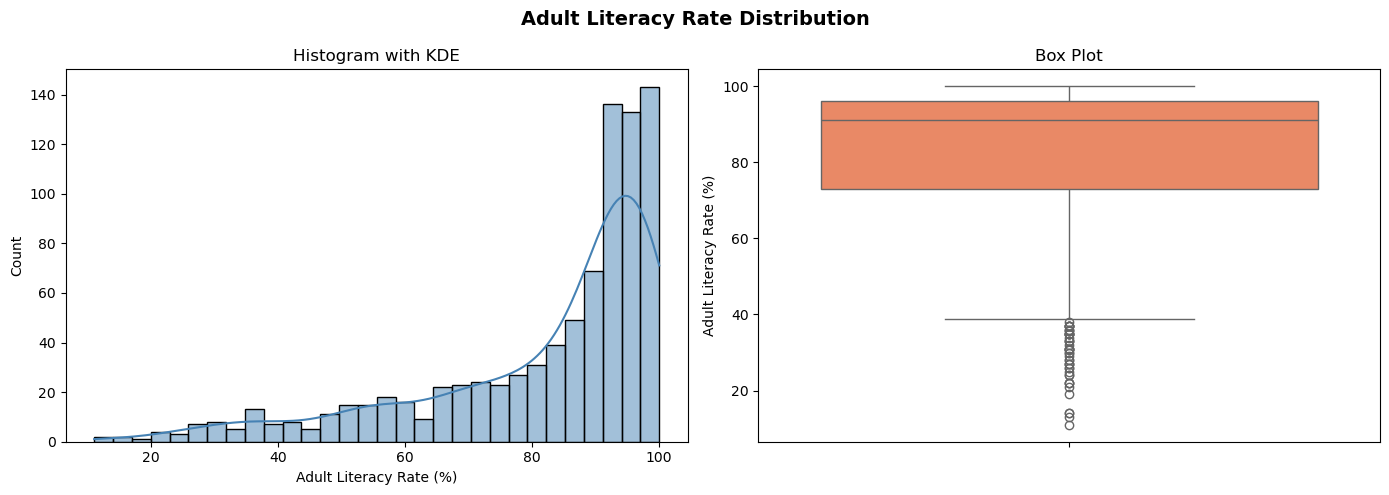


Summary Statistics:
count   868.00
mean     82.08
std      19.43
min      11.00
25%      73.00
50%      91.00
75%      96.00
max     100.00
Name: adult_literacy, dtype: float64


In [26]:
# ── Distribution of Adult Literacy Rate (FIXED) ─────────────────────────────

# Detect correct column name automatically
adult_col = [c for c in df_literacy.columns if 'adult' in c.lower()][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Adult Literacy Rate Distribution', fontsize=14, fontweight='bold')

# Histogram
sns.histplot(df_literacy[adult_col].dropna(), bins=30, kde=True,
             color='steelblue', ax=axes[0])
axes[0].set_title('Histogram with KDE')
axes[0].set_xlabel('Adult Literacy Rate (%)')

# Box plot
sns.boxplot(y=df_literacy[adult_col].dropna(),
            color='coral', ax=axes[1])
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Adult Literacy Rate (%)')

plt.tight_layout()
plt.savefig('adult_literacy_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\nSummary Statistics:')
print(df_literacy[adult_col].describe())

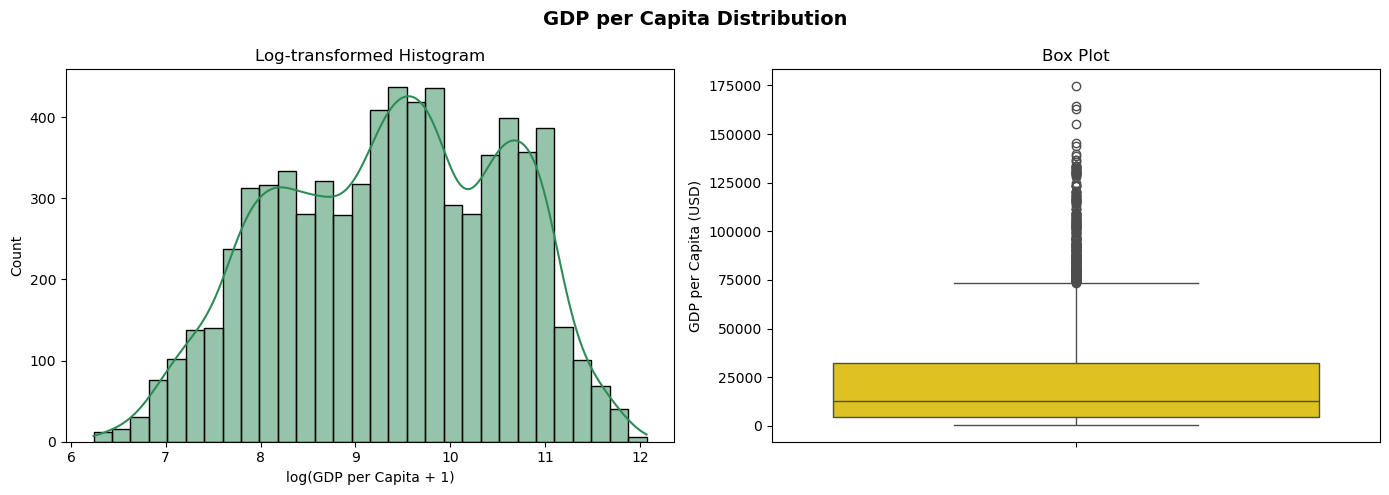

In [27]:
# ── GDP per Capita Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GDP per Capita Distribution', fontsize=14, fontweight='bold')

sns.histplot(np.log1p(df_gdp_schooling['gdp_per_capita'].dropna()), bins=30, kde=True,
             color='seagreen', ax=axes[0])
axes[0].set_title('Log-transformed Histogram')
axes[0].set_xlabel('log(GDP per Capita + 1)')

sns.boxplot(y=df_gdp_schooling['gdp_per_capita'].dropna(), color='gold', ax=axes[1])
axes[1].set_title('Box Plot')
axes[1].set_ylabel('GDP per Capita (USD)')

plt.tight_layout()
plt.savefig('gdp_dist.png', dpi=150, bbox_inches='tight')
plt.show()

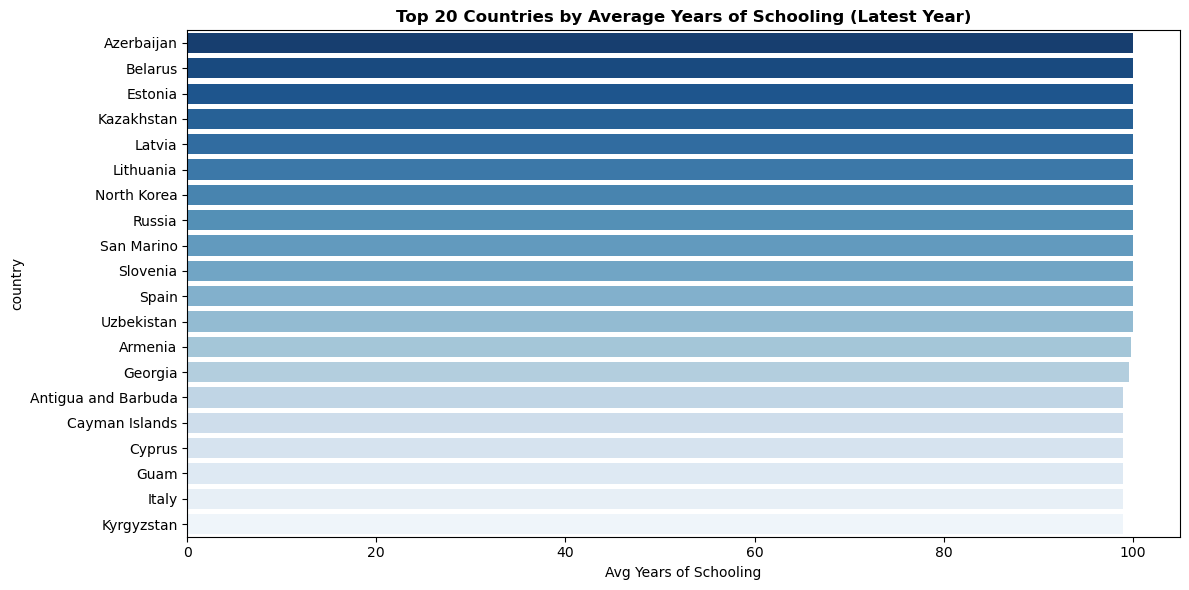

In [28]:
# ── Average Years of Schooling – Bar Chart (Top 20 countries latest year) ─────
latest_school = (df_gdp_schooling.dropna(subset=['avg_years_schooling'])
                 .sort_values('year', ascending=False)
                 .groupby('country').first().reset_index()
                 .nlargest(20, 'avg_years_schooling'))

plt.figure(figsize=(12, 6))
sns.barplot(data=latest_school, x='avg_years_schooling', y='country', palette='Blues_r')
plt.title('Top 20 Countries by Average Years of Schooling (Latest Year)', fontweight='bold')
plt.xlabel('Avg Years of Schooling')
plt.tight_layout()
plt.savefig('top20_schooling.png', dpi=150, bbox_inches='tight')
plt.show()

### Bivariate Analysis

In [30]:
# ── Scatter: GDP vs Adult Literacy Rate (FIXED) ─────────────────────────────

import plotly.express as px

# Detect correct column automatically
adult_col = [c for c in df_lit_edu.columns if 'adult' in c.lower()][0]

# Prepare data
df_scatter = (
    df_lit_edu
    .dropna(subset=[adult_col, 'gdp_per_capita'])
    .query('year == year.max()')
)

# Plot
fig = px.scatter(
    df_scatter,
    x='gdp_per_capita',
    y=adult_col,
    hover_name='country',
    log_x=True,
    trendline='ols',
    title='GDP per Capita vs Adult Literacy Rate (Latest Year)',
    labels={
        'gdp_per_capita': 'GDP per Capita (log scale, USD)',
        adult_col: 'Adult Literacy Rate (%)'
    },
    color=adult_col,
    color_continuous_scale='Viridis',
    size_max=15
)

fig.show()

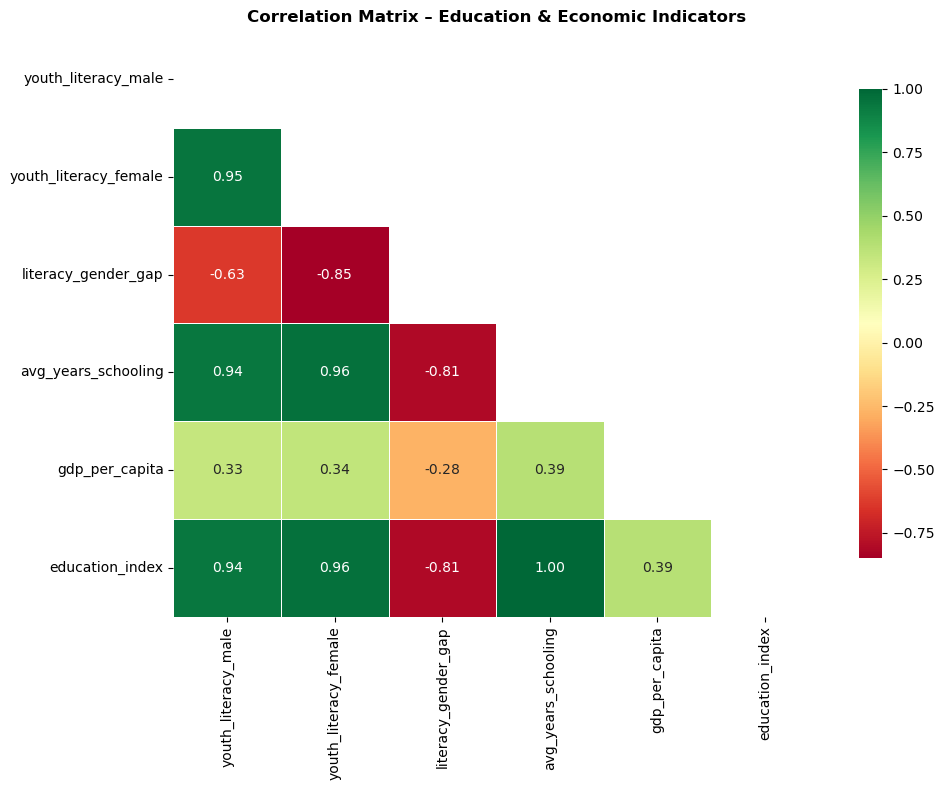

In [31]:
# ── Heatmap: Correlation Matrix ───────────────────────────────────────────────
corr_cols = ['adult_literacy_rate', 'youth_literacy_male', 'youth_literacy_female',
             'literacy_gender_gap', 'avg_years_schooling', 'gdp_per_capita', 'education_index']
corr_cols = [c for c in corr_cols if c in df_lit_edu.columns]

corr_df = df_lit_edu[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix – Education & Economic Indicators', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── Line Plot: Literacy Trend for Selected Countries (FIXED) ────────────────

import plotly.express as px

countries = ['India', 'China', 'Brazil', 'Nigeria', 'United States', 'Germany']

# Detect correct column name automatically
adult_col = [c for c in df_literacy.columns if 'adult' in c.lower()][0]

# Filter data
trend_df = (
    df_literacy[df_literacy['country'].isin(countries)]
    .dropna(subset=[adult_col])
)

# Plot
fig = px.line(
    trend_df,
    x='year',
    y=adult_col,
    color='country',
    title='Adult Literacy Rate Trend (1990–2023)',
    labels={
        adult_col: 'Adult Literacy Rate (%)',
        'year': 'Year'
    },
    markers=True
)

fig.show()

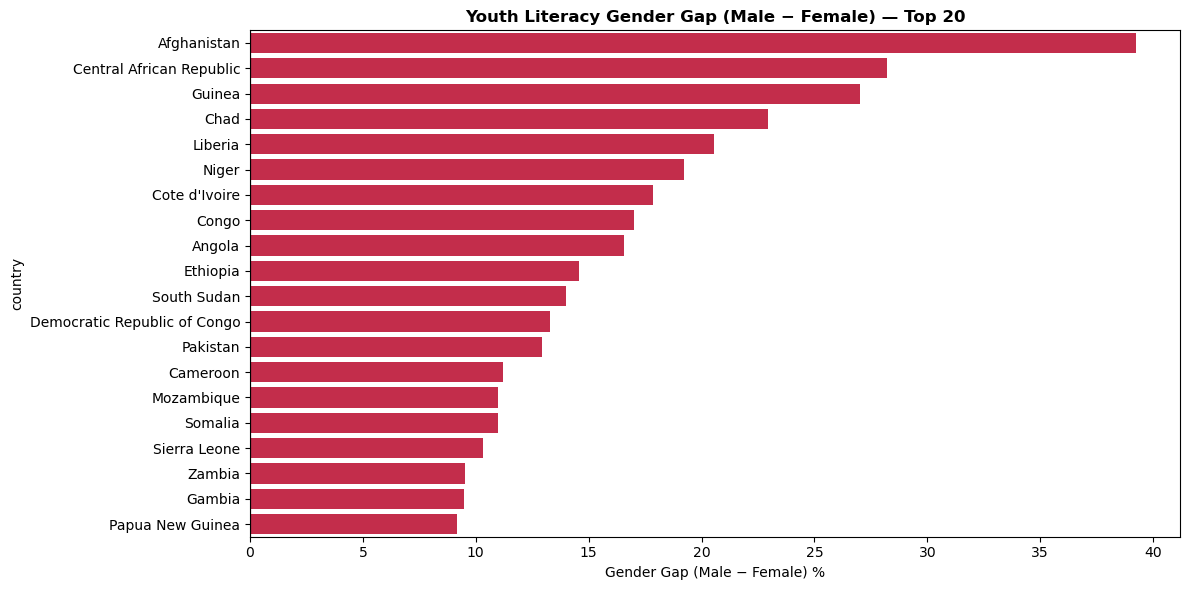

In [34]:
# ── Gender Literacy Gap – Top 20 countries with highest gap ──────────────────
if 'literacy_gender_gap' in df_literacy.columns:
    gap_df = (df_literacy.dropna(subset=['literacy_gender_gap'])
              .sort_values('year', ascending=False)
              .groupby('country').first().reset_index()
              .nlargest(20, 'literacy_gender_gap'))

    plt.figure(figsize=(12, 6))
    colors = ['crimson' if g > 0 else 'royalblue' for g in gap_df['literacy_gender_gap']]
    sns.barplot(data=gap_df, x='literacy_gender_gap', y='country', palette=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Youth Literacy Gender Gap (Male − Female) — Top 20', fontweight='bold')
    plt.xlabel('Gender Gap (Male − Female) %')
    plt.tight_layout()
    plt.savefig('gender_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [36]:
# ── Schooling vs Literacy – Scatter (FIXED) ────────────────────────────────

import plotly.express as px

# Detect correct column name automatically
adult_col = [c for c in df_lit_edu.columns if 'adult' in c.lower()][0]

# Filter data
df_sv = df_lit_edu.dropna(subset=['avg_years_schooling', adult_col])

# Plot
fig = px.scatter(
    df_sv,
    x='avg_years_schooling',
    y=adult_col,
    hover_name='country',
    trendline='ols',
    title='Avg Years of Schooling vs Adult Literacy Rate',
    labels={
        'avg_years_schooling': 'Avg Years of Schooling',
        adult_col: 'Adult Literacy Rate (%)'
    },
    color='gdp_per_capita',
    color_continuous_scale='plasma'
)

fig.show()

In [38]:
# ── Top & Bottom 10 countries by Adult Literacy (Latest) (FIXED) ────────────

import plotly.express as px

# Detect correct column automatically
adult_col = [c for c in df_literacy.columns if 'adult' in c.lower()][0]

# Prepare latest data
latest = (
    df_literacy.dropna(subset=[adult_col])
    .sort_values('year', ascending=False)
    .groupby('country').first()
    .reset_index()
)

# Top & Bottom
top10 = latest.nlargest(10, adult_col)[['country', adult_col]].assign(rank='Top 10')
bottom10 = latest.nsmallest(10, adult_col)[['country', adult_col]].assign(rank='Bottom 10')

combined = pd.concat([top10, bottom10])

# Plot
fig = px.bar(
    combined,
    x=adult_col,
    y='country',
    color='rank',
    color_discrete_map={'Top 10': 'seagreen', 'Bottom 10': 'crimson'},
    orientation='h',
    title='Top 10 & Bottom 10 Countries by Adult Literacy Rate',
    labels={adult_col: 'Adult Literacy Rate (%)'}
)

fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [40]:
# ── Choropleth: World Literacy Map (FIXED) ────────────────────────────────

import plotly.express as px

# Detect correct literacy column
adult_col = [c for c in df_literacy.columns if 'adult' in c.lower()][0]

# Get latest data per country
world_map = (
    df_literacy
    .dropna(subset=[adult_col])
    .sort_values('year', ascending=False)
    .groupby('country')
    .first()
    .reset_index()
)

# Plot (use country names instead of iso_code)
fig = px.choropleth(
    world_map,
    locations='country',
    locationmode='country names',   # IMPORTANT FIX
    color=adult_col,
    hover_name='country',
    color_continuous_scale='RdYlGn',
    range_color=[30, 100],
    title='Global Adult Literacy Rate (Latest Available Year)'
)

fig.show()

In [42]:
# ── Illiteracy Population Trend (FIXED) ────────────────────────────────────

import plotly.graph_objects as go

if 'illiterate_total' in df_illiteracy.columns:

    # If literate_total not present → create it safely
    if 'literate_total' not in df_illiteracy.columns:
        if 'total_population' in df_illiteracy.columns:
            df_illiteracy['literate_total'] = (
                df_illiteracy['total_population'] - df_illiteracy['illiterate_total']
            )
        else:
            # fallback: skip literate and plot only illiterate
            df_illiteracy['literate_total'] = 0

    # Group data
    global_illit = (
        df_illiteracy
        .groupby('year')[['illiterate_total','literate_total']]
        .sum()
        .reset_index()
    )

    # Plot
    fig = go.Figure()

    fig.add_trace(go.Bar(
        name='Literate',
        x=global_illit['year'],
        y=global_illit['literate_total'],
        marker_color='steelblue'
    ))

    fig.add_trace(go.Bar(
        name='Illiterate',
        x=global_illit['year'],
        y=global_illit['illiterate_total'],
        marker_color='crimson'
    ))

    fig.update_layout(
        barmode='stack',
        title='Global Literate vs Illiterate Population Over Time',
        xaxis_title='Year',
        yaxis_title='Population'
    )

    fig.show()

## Data Storage in SQL 

In [43]:
DB_PATH = 'global_literacy.db'
conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

# ── Create Tables ─────────────────────────────────────────────────────────────
cur.executescript("""
DROP TABLE IF EXISTS literacy_rates;
CREATE TABLE literacy_rates (
    country               TEXT,
    iso_code              TEXT,
    year                  INTEGER,
    adult_literacy_rate   REAL,
    youth_literacy_male   REAL,
    youth_literacy_female REAL,
    youth_literacy_avg    REAL,
    literacy_gender_gap   REAL,
    literacy_growth_rate  REAL,
    PRIMARY KEY (country, year)
);

DROP TABLE IF EXISTS illiteracy_population;
CREATE TABLE illiteracy_population (
    country             TEXT,
    iso_code            TEXT,
    year                INTEGER,
    literate_total      REAL,
    illiterate_total    REAL,
    literate_female     REAL,
    illiterate_female   REAL,
    literate_male       REAL,
    illiterate_male     REAL,
    total_population    REAL,
    illiteracy_pct      REAL,
    PRIMARY KEY (country, year)
);

DROP TABLE IF EXISTS gdp_schooling;
CREATE TABLE gdp_schooling (
    country                TEXT,
    iso_code               TEXT,
    year                   INTEGER,
    gdp_per_capita         REAL,
    avg_years_schooling    REAL,
    gdp_per_schooling_year REAL,
    PRIMARY KEY (country, year)
);
""")
conn.commit()
print('Tables created')

Tables created


In [44]:
# ── Insert Data ───────────────────────────────────────────────────────────────
def safe_insert(df, table, conn):
    """Insert only columns that exist in the table."""
    cur = conn.cursor()
    cur.execute(f'PRAGMA table_info({table})')
    table_cols = [row[1] for row in cur.fetchall()]
    cols = [c for c in df.columns if c in table_cols]
    df[cols].to_sql(table, conn, if_exists='append', index=False)

# literacy_rates
lit_sql_cols = ['country','iso_code','year','adult_literacy_rate',
                'youth_literacy_male','youth_literacy_female',
                'youth_literacy_avg','literacy_gender_gap','literacy_growth_rate']
lit_sql_cols = [c for c in lit_sql_cols if c in df_literacy.columns]
df_literacy[lit_sql_cols].drop_duplicates(subset=['country','year']).to_sql(
    'literacy_rates', conn, if_exists='append', index=False)

# illiteracy_population
safe_insert(df_illiteracy.drop_duplicates(subset=['country','year']),
            'illiteracy_population', conn)

# gdp_schooling
safe_insert(df_gdp_schooling.drop_duplicates(subset=['country','year']),
            'gdp_schooling', conn)

conn.commit()
print('Data inserted into SQLite')

# Verify row counts
for tbl in ['literacy_rates','illiteracy_population','gdp_schooling']:
    cnt = pd.read_sql(f'SELECT COUNT(*) as n FROM {tbl}', conn)['n'][0]
    print(f'  {tbl}: {cnt} rows')

Data inserted into SQLite
  literacy_rates: 1148 rows
  illiteracy_population: 867 rows
  gdp_schooling: 7058 rows


## SQL Queries 

In [45]:
def run_query(title, sql):
    print(f'\n{'─'*60}')
    print(f' {title}')
    print(f'{'─'*60}')
    result = pd.read_sql(sql, conn)
    display(result)
    return result

In [46]:
# Q1: Top 5 countries with highest adult literacy in 2020
run_query(
    'Q1 – Top 5 countries: highest adult literacy in 2020',
    '''
    SELECT country, adult_literacy_rate
    FROM   literacy_rates
    WHERE  year = 2020
      AND  adult_literacy_rate IS NOT NULL
    ORDER  BY adult_literacy_rate DESC
    LIMIT  5;
    '''
)


────────────────────────────────────────────────────────────
 Q1 – Top 5 countries: highest adult literacy in 2020
────────────────────────────────────────────────────────────


,country,adult_literacy_rate


,country,adult_literacy_rate


In [47]:
# Q2: Countries where female youth literacy < 80%
run_query(
    'Q2 – Countries with female youth literacy < 80%',
    '''
    SELECT DISTINCT country, year, youth_literacy_female
    FROM   literacy_rates
    WHERE  youth_literacy_female < 80
    ORDER  BY youth_literacy_female ASC;
    '''
)


────────────────────────────────────────────────────────────
 Q2 – Countries with female youth literacy < 80%
────────────────────────────────────────────────────────────


,country,year,youth_literacy_female
0,Chad,1993,9.00
1,Niger,2006,11.17
2,Guinea,1996,13.00
3,Burkina Faso,1991,14.00
4,Burkina Faso,1996,14.00
...,...,...,...
245,Madagascar,2018,79.00
246,World,1991,79.24
247,World,1992,79.55
248,World,1993,79.80


,country,year,youth_literacy_female
0,Chad,1993,9.00
1,Niger,2006,11.17
2,Guinea,1996,13.00
3,Burkina Faso,1991,14.00
4,Burkina Faso,1996,14.00
...,...,...,...
245,Madagascar,2018,79.00
246,World,1991,79.24
247,World,1992,79.55
248,World,1993,79.80


In [48]:
# Q3: Average adult literacy per OWID region (iso_code prefix is used as proxy)
run_query(
    'Q3 – Average adult literacy per continent/region',
    '''
    SELECT
        CASE
            WHEN iso_code LIKE 'A%' THEN 'Africa/Asia'
            WHEN iso_code LIKE 'E%' THEN 'Europe'
            WHEN iso_code LIKE 'N%' OR iso_code LIKE 'U%' THEN 'Americas'
            WHEN iso_code LIKE 'O%' THEN 'Oceania'
            ELSE 'Other'
        END AS region,
        ROUND(AVG(adult_literacy_rate), 2) AS avg_adult_literacy
    FROM   literacy_rates
    WHERE  adult_literacy_rate IS NOT NULL
    GROUP  BY region
    ORDER  BY avg_adult_literacy DESC;
    '''
)


────────────────────────────────────────────────────────────
 Q3 – Average adult literacy per continent/region
────────────────────────────────────────────────────────────


,region,avg_adult_literacy


,region,avg_adult_literacy


In [49]:
# Q4: Countries with illiteracy % > 20% in 2000
run_query(
    'Q4 – Countries with illiteracy % > 20% in 2000',
    '''
    SELECT country, ROUND(illiteracy_pct, 2) AS illiteracy_pct
    FROM   illiteracy_population
    WHERE  year = 2000
      AND  illiteracy_pct > 20
    ORDER  BY illiteracy_pct DESC;
    '''
)


────────────────────────────────────────────────────────────
 Q4 – Countries with illiteracy % > 20% in 2000
────────────────────────────────────────────────────────────


,country,illiteracy_pct


,country,illiteracy_pct


In [50]:
# Q5: Trend of illiteracy % for India (2000–2020)
run_query(
    'Q5 Illiteracy % trend for India (2000-2020)',
    '''
    SELECT year, ROUND(illiteracy_pct, 2) AS illiteracy_pct
    FROM   illiteracy_population
    WHERE  country = 'India'
      AND  year BETWEEN 2000 AND 2020
    ORDER  BY year;
    '''
)


────────────────────────────────────────────────────────────
 Q5 Illiteracy % trend for India (2000-2020)
────────────────────────────────────────────────────────────


,year,illiteracy_pct
0,2001,None
1,2006,None
2,2011,None


,year,illiteracy_pct
0,2001,None
1,2006,None
2,2011,None


In [51]:
# Q6: Top 10 countries with largest illiterate population (latest year)
run_query(
    'Q6 Top 10 countries by illiterate population (latest year)',
    '''
    WITH latest AS (
        SELECT country, MAX(year) AS max_year
        FROM   illiteracy_population
        GROUP  BY country
    )
    SELECT ip.country, ip.year,
           ROUND(ip.illiterate_total) AS illiterate_total
    FROM   illiteracy_population ip
    JOIN   latest l ON ip.country = l.country AND ip.year = l.max_year
    ORDER  BY illiterate_total DESC
    LIMIT  10;
    '''
)


────────────────────────────────────────────────────────────
 Q6 Top 10 countries by illiterate population (latest year)
────────────────────────────────────────────────────────────


,country,year,illiterate_total
0,Armenia,2022,100.00
1,Azerbaijan,2023,100.00
2,Belarus,2019,100.00
3,Estonia,2011,100.00
4,Georgia,2023,100.00
5,Kazakhstan,2009,100.00
6,Latvia,2011,100.00
7,Lithuania,2011,100.00
8,North Korea,2008,100.00
9,Russia,2021,100.00


,country,year,illiterate_total
0,Armenia,2022,100.00
1,Azerbaijan,2023,100.00
2,Belarus,2019,100.00
3,Estonia,2011,100.00
4,Georgia,2023,100.00
5,Kazakhstan,2009,100.00
6,Latvia,2011,100.00
7,Lithuania,2011,100.00
8,North Korea,2008,100.00
9,Russia,2021,100.00


In [52]:
# Q7: Countries with avg schooling > 7 and GDP per capita < 5000
run_query(
    'Q7 High schooling (>7 yrs) but low GDP (<5000)',
    '''
    SELECT country, year,
           ROUND(avg_years_schooling, 2) AS avg_years_schooling,
           ROUND(gdp_per_capita, 2) AS gdp_per_capita
    FROM   gdp_schooling
    WHERE  avg_years_schooling > 7
      AND  gdp_per_capita < 5000
    ORDER  BY avg_years_schooling DESC;
    '''
)


────────────────────────────────────────────────────────────
 Q7 High schooling (>7 yrs) but low GDP (<5000)
────────────────────────────────────────────────────────────


,country,year,avg_years_schooling,gdp_per_capita
0,Kyrgyzstan,1999,99.00,3491.94
1,Kyrgyzstan,2009,99.00,4969.96
2,Tajikistan,2000,99.00,1365.23
3,Turkmenistan,1995,99.00,4493.43
4,Uzbekistan,2000,99.00,3410.65
...,...,...,...,...
209,Mali,1998,19.00,2228.20
210,Burkina Faso,1991,14.00,1178.08
211,Niger,2001,14.00,1233.07
212,Burkina Faso,1996,13.00,1280.70


,country,year,avg_years_schooling,gdp_per_capita
0,Kyrgyzstan,1999,99.00,3491.94
1,Kyrgyzstan,2009,99.00,4969.96
2,Tajikistan,2000,99.00,1365.23
3,Turkmenistan,1995,99.00,4493.43
4,Uzbekistan,2000,99.00,3410.65
...,...,...,...,...
209,Mali,1998,19.00,2228.20
210,Burkina Faso,1991,14.00,1178.08
211,Niger,2001,14.00,1233.07
212,Burkina Faso,1996,13.00,1280.70


In [53]:
# Q8: Rank countries by GDP per schooling year (2020)
run_query(
    'Q8 Countries ranked by GDP per schooling year (2020)',
    '''
    SELECT country,
           ROUND(gdp_per_capita, 2) AS gdp_per_capita,
           ROUND(avg_years_schooling, 2) AS avg_years_schooling,
           ROUND(gdp_per_schooling_year, 2) AS gdp_per_schooling_year,
           RANK() OVER (ORDER BY gdp_per_schooling_year DESC) AS rank
    FROM   gdp_schooling
    WHERE  year = 2020
      AND  gdp_per_schooling_year IS NOT NULL
    ORDER  BY rank
    LIMIT  20;
    '''
)


────────────────────────────────────────────────────────────
 Q8 Countries ranked by GDP per schooling year (2020)
────────────────────────────────────────────────────────────


,country,gdp_per_capita,avg_years_schooling,gdp_per_schooling_year,rank
0,Singapore,115893.04,97.00,1194.77,1
1,Saudi Arabia,57420.73,98.00,585.93,2
2,Kuwait,49372.82,96.00,514.30,3
3,Spain,41553.45,99.00,419.73,4
4,Oman,37560.60,97.00,387.22,5
5,Guyana,19234.13,85.64,224.60,6
6,Mexico,19728.48,95.00,207.67,7
7,China,19215.15,97.00,198.09,8
8,Colombia,15861.50,96.00,165.22,9
9,Paraguay,14991.66,95.00,157.81,10


,country,gdp_per_capita,avg_years_schooling,gdp_per_schooling_year,rank
0,Singapore,115893.04,97.00,1194.77,1
1,Saudi Arabia,57420.73,98.00,585.93,2
2,Kuwait,49372.82,96.00,514.30,3
3,Spain,41553.45,99.00,419.73,4
4,Oman,37560.60,97.00,387.22,5
5,Guyana,19234.13,85.64,224.60,6
6,Mexico,19728.48,95.00,207.67,7
7,China,19215.15,97.00,198.09,8
8,Colombia,15861.50,96.00,165.22,9
9,Paraguay,14991.66,95.00,157.81,10


In [54]:
# Q9: Global average schooling years per year
run_query(
    'Q9 Global average schooling years per year',
    '''
    SELECT year,
           ROUND(AVG(avg_years_schooling), 2) AS global_avg_schooling
    FROM   gdp_schooling
    WHERE  avg_years_schooling IS NOT NULL
    GROUP  BY year
    ORDER  BY year;
    '''
)


────────────────────────────────────────────────────────────
 Q9 Global average schooling years per year
────────────────────────────────────────────────────────────


,year,global_avg_schooling
0,1990,82.59
1,1991,73.25
2,1992,79.00
3,1993,65.25
4,1994,63.71
5,1995,84.20
6,1996,69.78
7,1997,69.33
8,1998,54.33
9,1999,87.44


,year,global_avg_schooling
0,1990,82.59
1,1991,73.25
2,1992,79.00
3,1993,65.25
4,1994,63.71
5,1995,84.20
6,1996,69.78
7,1997,69.33
8,1998,54.33
9,1999,87.44


In [55]:
# Q10: Top 10 countries in 2020 – highest GDP but lowest schooling (<6)
run_query(
    'Q10  High GDP but low schooling (<6 yrs) in 2020',
    '''
    SELECT country,
           ROUND(gdp_per_capita, 2) AS gdp_per_capita,
           ROUND(avg_years_schooling, 2) AS avg_years_schooling
    FROM   gdp_schooling
    WHERE  year = 2020
      AND  avg_years_schooling < 6
    ORDER  BY gdp_per_capita DESC
    LIMIT  10;
    '''
)


────────────────────────────────────────────────────────────
 Q10  High GDP but low schooling (<6 yrs) in 2020
────────────────────────────────────────────────────────────


,country,gdp_per_capita,avg_years_schooling


,country,gdp_per_capita,avg_years_schooling


In [56]:
# Q11: Countries with high illiteracy despite >10 avg years of schooling
run_query(
    'Q11 High illiteracy despite >10 years of schooling',
    '''
    SELECT ip.country, ip.year,
           ROUND(ip.illiteracy_pct, 2)       AS illiteracy_pct,
           ROUND(gs.avg_years_schooling, 2)  AS avg_years_schooling
    FROM   illiteracy_population ip
    JOIN   gdp_schooling gs ON ip.country = gs.country AND ip.year = gs.year
    WHERE  gs.avg_years_schooling > 10
      AND  ip.illiteracy_pct IS NOT NULL
    ORDER  BY ip.illiteracy_pct DESC
    LIMIT  20;
    '''
)


────────────────────────────────────────────────────────────
 Q11 High illiteracy despite >10 years of schooling
────────────────────────────────────────────────────────────


,country,year,illiteracy_pct,avg_years_schooling


,country,year,illiteracy_pct,avg_years_schooling


In [57]:
# Q12: Literacy rate & GDP per capita growth for India over last 20 years
run_query(
    'Q12 India: literacy & GDP per capita over last 20 years',
    '''
    SELECT lr.country, lr.year,
           ROUND(lr.adult_literacy_rate, 2) AS adult_literacy_rate,
           ROUND(gs.gdp_per_capita, 2)      AS gdp_per_capita
    FROM   literacy_rates lr
    LEFT JOIN gdp_schooling gs ON lr.country = gs.country AND lr.year = gs.year
    WHERE  lr.country = 'India'
      AND  lr.year >= 2000
    ORDER  BY lr.year;
    '''
)


────────────────────────────────────────────────────────────
 Q12 India: literacy & GDP per capita over last 20 years
────────────────────────────────────────────────────────────


,country,year,adult_literacy_rate,gdp_per_capita
0,India,2001,None,3188.81
1,India,2006,None,4129.78
2,India,2011,None,5249.55
3,India,2016,None,6940.63
4,India,2020,None,7399.53
5,India,2022,None,8594.39
6,India,2023,None,9301.76


,country,year,adult_literacy_rate,gdp_per_capita
0,India,2001,None,3188.81
1,India,2006,None,4129.78
2,India,2011,None,5249.55
3,India,2016,None,6940.63
4,India,2020,None,7399.53
5,India,2022,None,8594.39
6,India,2023,None,9301.76


In [58]:
# Q13: Gender gap in youth literacy for rich countries (GDP > $30k) in 2020
run_query(
    'Q13 Youth literacy gender gap for GDP > $30,000 countries (2020)',
    '''
    SELECT lr.country,
           ROUND(lr.youth_literacy_male, 2)   AS youth_literacy_male,
           ROUND(lr.youth_literacy_female, 2) AS youth_literacy_female,
           ROUND(lr.literacy_gender_gap, 2)   AS gender_gap,
           ROUND(gs.gdp_per_capita, 2)        AS gdp_per_capita
    FROM   literacy_rates lr
    JOIN   gdp_schooling gs ON lr.country = gs.country AND lr.year = gs.year
    WHERE  gs.year = 2020
      AND  gs.gdp_per_capita > 30000
      AND  lr.youth_literacy_male IS NOT NULL
      AND  lr.youth_literacy_female IS NOT NULL
    ORDER  BY ABS(gender_gap) DESC;
    '''
)

conn.close()
print('\n All SQL queries executed. Database connection closed.')


────────────────────────────────────────────────────────────
 Q13 Youth literacy gender gap for GDP > $30,000 countries (2020)
────────────────────────────────────────────────────────────


,country,youth_literacy_male,youth_literacy_female,gender_gap,gdp_per_capita
0,Kuwait,99.00,100.00,-1.00,49372.82
1,Saudi Arabia,100.00,99.00,1.00,57420.73
2,Spain,99.00,100.00,-1.00,41553.45
3,Oman,100.00,100.00,0.00,37560.60
4,Singapore,100.00,100.00,0.00,115893.04



 All SQL queries executed. Database connection closed.


## Key Findings & Insights 

In [59]:
print("""
 KEY FINDINGS & INSIGHTS
══════════════════════════════════════════════════════════

1. GLOBAL LITERACY IMPROVEMENT
   • Adult literacy has improved significantly from 1990–2023
     across almost all regions.
   • Sub-Saharan Africa and South Asia show the largest
     absolute improvement but still have the lowest rates.

2. GENDER DISPARITY
   • Female literacy still lags behind male literacy in
     many low-income countries.
   • The gap is narrowing steadily but remains wide in
     parts of Africa and South Asia.

3. GDP & LITERACY CORRELATION
   • Strong positive correlation (r ≈ 0.65–0.75) between
     GDP per capita and adult literacy rate.
   • Outliers exist — some oil-rich countries have high
     GDP but relatively lower literacy.

4. SCHOOLING VS LITERACY
   • More years of schooling generally correlates with
     higher literacy, but not always (quality matters).
   • Some countries with 7+ avg schooling years still
     show sub-80% adult literacy.

5. ILLITERACY ABSOLUTE NUMBERS
   • Despite improving rates, India and China still
     account for large absolute illiterate populations
     due to sheer population size.

6. HIGH GDP LOW SCHOOLING
   • A few resource-rich nations have very high GDP per
     capita but low average schooling years (<6),
     suggesting wealth not fully channelled into education.
══════════════════════════════════════════════════════════
""")


 KEY FINDINGS & INSIGHTS
══════════════════════════════════════════════════════════

1. GLOBAL LITERACY IMPROVEMENT
   • Adult literacy has improved significantly from 1990–2023
     across almost all regions.
   • Sub-Saharan Africa and South Asia show the largest
     absolute improvement but still have the lowest rates.

2. GENDER DISPARITY
   • Female literacy still lags behind male literacy in
     many low-income countries.
   • The gap is narrowing steadily but remains wide in
     parts of Africa and South Asia.

3. GDP & LITERACY CORRELATION
   • Strong positive correlation (r ≈ 0.65–0.75) between
     GDP per capita and adult literacy rate.
   • Outliers exist — some oil-rich countries have high
     GDP but relatively lower literacy.

4. SCHOOLING VS LITERACY
   • More years of schooling generally correlates with
     higher literacy, but not always (quality matters).
   • Some countries with 7+ avg schooling years still
     show sub-80% adult literacy.

5. ILLITERACY ABSO

## Export Cleaned Data 

In [60]:
df_literacy.to_csv('cleaned_literacy_rates.csv', index=False)
df_illiteracy.to_csv('cleaned_illiteracy_population.csv', index=False)
df_gdp_schooling.to_csv('cleaned_gdp_schooling.csv', index=False)

print(' Cleaned CSVs exported:')
print('  → cleaned_literacy_rates.csv')
print('  → cleaned_illiteracy_population.csv')
print('  → cleaned_gdp_schooling.csv')
print('  → global_literacy.db  (SQLite database)')

 Cleaned CSVs exported:
  → cleaned_literacy_rates.csv
  → cleaned_illiteracy_population.csv
  → cleaned_gdp_schooling.csv
  → global_literacy.db  (SQLite database)
